In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans


df = pd.read_csv("/content/adult.csv")


In [ ]:
cont_sign = []
for i in df:
  res = (df[i] == '?').sum()
  if res > 0:
    cont_sign.append(i)
    print(f"{i}: {res}")
cont_sign

workclass: 1836
occupation: 1843
native.country: 583


['workclass', 'occupation', 'native.country']

In [ ]:
df.replace("?", np.nan, inplace=True)

###At this stage we found out that workclass, occupation and native country columns contain character '?'

In [ ]:
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)
df = df.drop_duplicates().reset_index(drop=True)

Duplicate rows: 24


In [ ]:
cont_zeros = []
for i in df:
  res = (df[i] == 0).sum()
  if res > 0:
    perc = res / len(df[i])
    cont_zeros.append(i)
    print(f"{i}: {res} with percentage: {perc*100:.2f}%")
cont_zeros

capital.gain: 29825 with percentage: 91.66%
capital.loss: 31018 with percentage: 95.33%


['capital.gain', 'capital.loss']

### Now we see that gain and loss columns contain TOO much zeros in the data exceeding 90%

So we are going to get rid of these columns since they do not have enough data

In [ ]:
df = df.drop(columns=cont_zeros)

In [ ]:
print("Missing values before:\n", df.isnull().sum())

Missing values before:
 age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
hours.per.week       0
native.country     582
income               0
dtype: int64


In [ ]:
df_fem = df["sex"] == "female"
df_fem

,sex
0,False
1,False
2,False
3,False
4,False
...,...
32532,False
32533,False
32534,False
32535,False


In [ ]:

cat_cols = df.select_dtypes(exclude=np.number).columns

In [ ]:
cat_cols = df.select_dtypes(include="object").columns
le = LabelEncoder()

for col in cat_cols:
    df[col] = df[col].astype(str)  # convert to string
    df[col] = le.fit_transform(df[col])


mean_imp = SimpleImputer(strategy="mean")
df_mean = pd.DataFrame(mean_imp.fit_transform(df), columns=df.columns)

median_imp = SimpleImputer(strategy="median")
df_median = pd.DataFrame(median_imp.fit_transform(df), columns=df.columns)

knn_imp = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(knn_imp.fit_transform(df), columns=df.columns)

print("\nMissing after Mean:\n", df_mean.isnull().sum().sum())
print("Missing after Median:\n", df_median.isnull().sum().sum())
print("Missing after KNN:\n", df_knn.isnull().sum().sum())



Missing after Mean:
 0
Missing after Median:
 0
Missing after KNN:
 0


In [ ]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,hours.per.week,native.country,income
0,90,8,77053,11,9,6,14,1,4,0,40,38,0
1,82,3,132870,11,9,6,3,1,4,0,18,38,0
2,66,8,186061,15,10,6,14,4,2,0,40,38,0
3,54,3,140359,5,4,0,6,4,4,0,40,38,0
4,41,3,264663,15,10,5,9,3,4,0,40,38,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32532,22,3,310152,15,10,4,10,1,4,1,40,38,0
32533,27,3,257302,7,12,2,12,5,4,0,38,38,0
32534,40,3,154374,11,9,2,6,0,4,1,40,38,1
32535,58,3,151910,11,9,6,0,4,4,0,40,38,0


In [ ]:
# # Outliers
# Q1 = df_knn.quantile(0.25)
# Q3 = df_knn.quantile(0.75)
# IQR = Q3 - Q1

# outliers = ((df_knn < (Q1 - 1.5 * IQR)) |
#             (df_knn > (Q3 + 1.5 * IQR)))

# df_knn = df_knn[~outliers.any(axis=1)]


In [ ]:
df_knn

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,hours.per.week,native.country,income
0,90.0,8.0,77053.0,11.0,9.0,6.0,14.0,1.0,4.0,0.0,40.0,38.0,0.0
1,82.0,3.0,132870.0,11.0,9.0,6.0,3.0,1.0,4.0,0.0,18.0,38.0,0.0
2,66.0,8.0,186061.0,15.0,10.0,6.0,14.0,4.0,2.0,0.0,40.0,38.0,0.0
3,54.0,3.0,140359.0,5.0,4.0,0.0,6.0,4.0,4.0,0.0,40.0,38.0,0.0
4,41.0,3.0,264663.0,15.0,10.0,5.0,9.0,3.0,4.0,0.0,40.0,38.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32532,22.0,3.0,310152.0,15.0,10.0,4.0,10.0,1.0,4.0,1.0,40.0,38.0,0.0
32533,27.0,3.0,257302.0,7.0,12.0,2.0,12.0,5.0,4.0,0.0,38.0,38.0,0.0
32534,40.0,3.0,154374.0,11.0,9.0,2.0,6.0,0.0,4.0,1.0,40.0,38.0,1.0
32535,58.0,3.0,151910.0,11.0,9.0,6.0,0.0,4.0,4.0,0.0,40.0,38.0,0.0


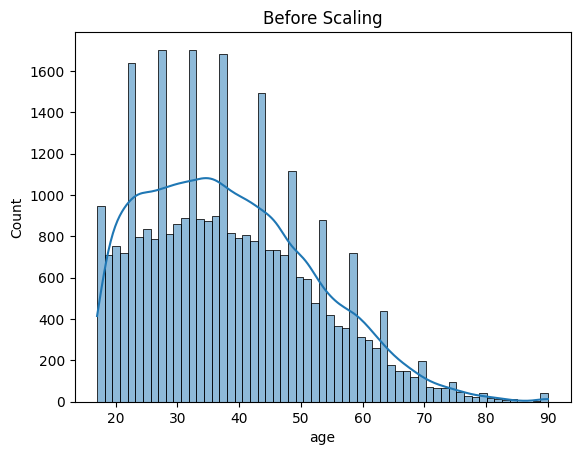

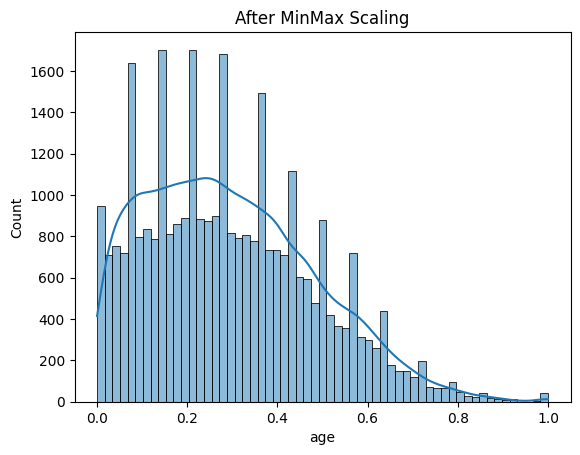

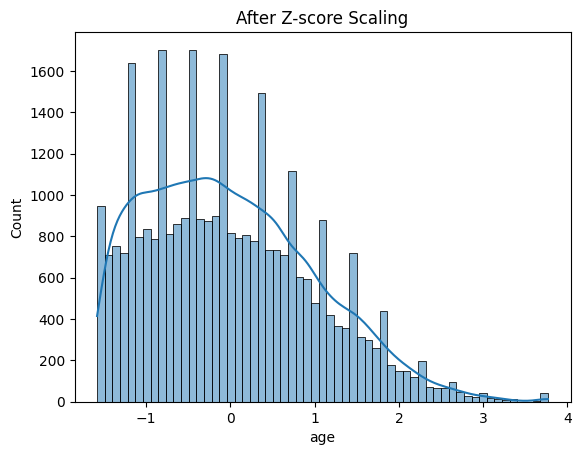

In [ ]:
plt.figure()
sns.histplot(df_knn.iloc[:, 0], kde=True)
plt.title("Before Scaling")
plt.show()

minmax = MinMaxScaler()
df_minmax = pd.DataFrame(minmax.fit_transform(df_knn.iloc[:, :-1]),
                         columns=df_knn.columns[:-1])

standard = StandardScaler()
df_standard = pd.DataFrame(standard.fit_transform(df_knn.iloc[:, :-1]),
                           columns=df_knn.columns[:-1])

plt.figure()
sns.histplot(df_minmax.iloc[:, 0], kde=True)
plt.title("After MinMax Scaling")
plt.show()

plt.figure()
sns.histplot(df_standard.iloc[:, 0], kde=True)
plt.title("After Z-score Scaling")
plt.show()

[[ 0.29771596 -1.81131591  3.51638748 ...  3.54543064 -0.93291066
  -0.31663597]
 [ 0.93868021 -0.11446399  0.24827587 ...  2.46053919 -0.63070579
  -0.35145894]
 [ 2.14779309 -0.57138833  3.39969555 ...  2.66395745 -0.89686103
   0.574789  ]
 ...
 [-1.05278137 -0.26483277 -0.20867941 ... -0.42927434 -0.34061461
  -0.19992534]
 [ 1.83747533  0.90779009 -0.54533102 ...  2.65600696 -0.43267795
   0.61752701]
 [ 1.46135619  0.40374585 -0.91207371 ... -0.54028262  0.50449003
   0.8899722 ]]


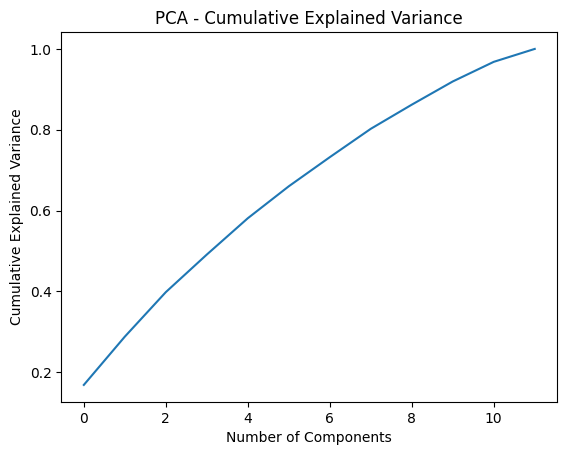

In [ ]:
pca = PCA()
pca_data = pca.fit_transform(df_standard)
print(pca_data)
cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure()
plt.plot(cum_var)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.show()

In [ ]:
col = df_knn.columns[0]

# Equal-width binning
equal_width = pd.cut(df_knn[col], bins=5)

# Equal-frequency binning
equal_freq = pd.qcut(df_knn[col], q=5)

# KMeans discretization
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(df_knn[[col]])

print("\nEqual Width Bins:\n", equal_width.value_counts())
print("\nEqual Frequency Bins:\n", equal_freq.value_counts())
print("\nKMeans Clusters:\n", pd.Series(kmeans_labels).value_counts())




Equal Width Bins:
 age
(31.6, 46.2]      12204
(16.927, 31.6]    11446
(46.2, 60.8]       6556
(60.8, 75.4]       2091
(75.4, 90.0]        240
Name: count, dtype: int64

Equal Frequency Bins:
 age
(16.999, 26.0]    7185
(33.0, 41.0]      6760
(50.0, 90.0]      6459
(41.0, 50.0]      6169
(26.0, 33.0]      5964
Name: count, dtype: int64

KMeans Clusters:
 1    9698
2    9403
3    6977
0    4428
4    2031
Name: count, dtype: int64


In [ ]:
target = df_kn.iloc[:, -1]
X = df_standard.iloc[:, :-1]
y = target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (26029, 12)
Test shape: (6508, 12)


# Lab work 5 part

In [ ]:
df_standard

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,hours.per.week,native.country,income
0,3.770003,2.921515,-1.067955,0.181519,-0.420679,2.249634,1.750326,-0.277864,0.393685,-1.422436,-0.035664,0.251146,-0.563377
1,3.183397,-0.237964,-0.539159,0.181519,-0.420679,2.249634,-0.790564,-0.277864,0.393685,-1.422436,-1.817516,0.251146,-0.563377
2,2.010185,2.921515,-0.035241,1.215089,-0.031815,2.249634,1.750326,1.588923,-1.962488,-1.422436,-0.035664,0.251146,-0.563377
3,1.130276,-0.237964,-0.468210,-1.368836,-2.364998,-1.733696,-0.097594,1.588923,0.393685,-1.422436,-0.035664,0.251146,-0.563377
4,0.177041,-0.237964,0.709415,1.215089,-0.031815,1.585746,0.595376,0.966661,0.393685,-1.422436,-0.035664,0.251146,-0.563377
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32532,-1.216148,-0.237964,1.140366,1.215089,-0.031815,0.921857,0.826366,-0.277864,0.393685,0.703020,-0.035664,0.251146,-0.563377
32533,-0.849519,-0.237964,0.639678,-0.852051,0.745913,-0.405919,1.288346,2.211186,0.393685,-1.422436,-0.197650,0.251146,-0.563377
32534,0.103716,-0.237964,-0.335436,0.181519,-0.420679,-0.405919,-0.097594,-0.900126,0.393685,0.703020,-0.035664,0.251146,1.775009
32535,1.423579,-0.237964,-0.358779,0.181519,-0.420679,2.249634,-1.483535,1.588923,0.393685,-1.422436,-0.035664,0.251146,-0.563377


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [ ]:
X = df_standard.iloc[:, :-1]
y = df_knn.iloc[:, -1]

y = np.array(y)
X = np.array(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
hidden_sizes = [10, 20, 50, 100]
activations = ["relu", "tanh", "logistic"]
results = {}

In [ ]:
for act in activations:
    for h in hidden_sizes:
        mlp = MLPClassifier(
            hidden_layer_sizes=(h,),
            activation=act,
            max_iter=100,
            random_state=42
        )

        mlp.fit(X_train, y_train)

        y_train_pred = mlp.predict(X_train)
        y_test_pred = mlp.predict(X_test)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        results[(act, h)] = {
            "train_acc": train_acc,
            "test_acc": test_acc,
            "loss_curve": mlp.loss_curve_
        }

        print(f"Activation={act}, Hidden={h}, Train={train_acc:.4f}, Test={test_acc:.4f}")

Activation=relu, Hidden=10, Train=0.8359, Test=0.8301


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Activation=relu, Hidden=20, Train=0.8371, Test=0.8313


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Activation=relu, Hidden=50, Train=0.8399, Test=0.8317


...

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Activation=logistic, Hidden=20, Train=0.8340, Test=0.8313


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Activation=logistic, Hidden=50, Train=0.8356, Test=0.8313
Activation=logistic, Hidden=100, Train=0.8367, Test=0.8327


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
fig, ax = plt.subplots(3, 4, figsize=(15, 15))
for i, a in enumerate(activations):
  for j, h in enumerate(hidden_sizes):
    ax[i, j].plot(results[(a, h)]["loss_curve"]);
    ax[i, j].set_title(f"Loss curve {a} | hidden layers: {h}")

In [ ]:
for act in activations:
    print(f"\nActivation: {act}")
    print("Hidden\tTrain Acc\tTest Acc")
    for h in hidden_sizes:
        r = results[(act, h)]
        print(f"{h}\t{r['train_acc']:.4f}\t\t{r['test_acc']:.4f}")